In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import multiprocessing

# Configure multiprocessing to prevent cleanup errors
multiprocessing.set_start_method('fork', force=True)  # Safer for Jupyter notebooks

In [2]:
# Load the dataset
df = pd.read_csv('crop_yield.csv').sample(n=50000, random_state=42)

In [3]:

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nColumn Names and Data Types:")
print(df.dtypes)
print("\nDataset Info:")
df.info()
print("\nFirst 5 rows of the dataset:")
df.head()

Dataset Shape: (50000, 10)

Column Names and Data Types:
Region                     object
Soil_Type                  object
Crop                       object
Rainfall_mm               float64
Temperature_Celsius       float64
Fertilizer_Used              bool
Irrigation_Used              bool
Weather_Condition          object
Days_to_Harvest             int64
Yield_tons_per_hectare    float64
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 987231 to 120934
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Region                  50000 non-null  object 
 1   Soil_Type               50000 non-null  object 
 2   Crop                    50000 non-null  object 
 3   Rainfall_mm             50000 non-null  float64
 4   Temperature_Celsius     50000 non-null  float64
 5   Fertilizer_Used         50000 non-null  bool   
 6   Irrigation_Used         50000 non-n

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
987231,West,Silt,Cotton,714.854403,23.875872,False,False,Sunny,120,3.840988
79954,North,Chalky,Cotton,860.604672,23.070897,False,False,Rainy,78,5.138173
567130,North,Sandy,Barley,802.081954,24.020125,True,True,Rainy,140,6.401523
500891,West,Chalky,Cotton,203.616909,16.895211,False,True,Sunny,96,2.658805
55399,East,Silt,Rice,510.528102,18.402903,False,True,Cloudy,65,2.797703


In [4]:
# Preprocess categorical variables using One-Hot Encoding

# Convert boolean columns to 0 and 1
df['Fertilizer_Used'] = df['Fertilizer_Used'].astype(int)
df['Irrigation_Used'] = df['Irrigation_Used'].astype(int)

# Apply One-Hot Encoding to categorical columns
categorical_columns = ['Region', 'Soil_Type', 'Crop', 'Weather_Condition']
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=False)

print("Shape after encoding:", df_encoded.shape)
print("\nNew columns created:")
print(df_encoded.columns.tolist())

Shape after encoding: (50000, 25)

New columns created:
['Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used', 'Days_to_Harvest', 'Yield_tons_per_hectare', 'Region_East', 'Region_North', 'Region_South', 'Region_West', 'Soil_Type_Chalky', 'Soil_Type_Clay', 'Soil_Type_Loam', 'Soil_Type_Peaty', 'Soil_Type_Sandy', 'Soil_Type_Silt', 'Crop_Barley', 'Crop_Cotton', 'Crop_Maize', 'Crop_Rice', 'Crop_Soybean', 'Crop_Wheat', 'Weather_Condition_Cloudy', 'Weather_Condition_Rainy', 'Weather_Condition_Sunny']


In [5]:
# Separate features and target
X = df_encoded.drop('Yield_tons_per_hectare', axis=1)
y = df_encoded['Yield_tons_per_hectare']

# Initialize and fit the scaler on numerical features
numerical_features = ['Rainfall_mm', 'Temperature_Celsius', 'Days_to_Harvest']
scaler = StandardScaler()

# Create a copy of X to avoid modifying the original
X_scaled = X.copy()

# Scale the numerical features
X_scaled[numerical_features] = scaler.fit_transform(X[numerical_features])

print("Original numerical feature ranges:")
print(X[numerical_features].describe())
print("\nScaled numerical feature ranges:")
print(X_scaled[numerical_features].describe())

Original numerical feature ranges:
        Rainfall_mm  Temperature_Celsius  Days_to_Harvest
count  50000.000000         50000.000000     50000.000000
mean     550.873464            27.428304       104.606020
std      259.774683             7.232036        25.891184
min      100.014436            15.000293        60.000000
25%      325.922479            21.147400        82.000000
50%      550.282067            27.420328       105.000000
75%      774.424456            33.671448       127.000000
max      999.981534            39.999628       149.000000

Scaled numerical feature ranges:
        Rainfall_mm  Temperature_Celsius  Days_to_Harvest
count  5.000000e+04         5.000000e+04     5.000000e+04
mean   5.266543e-16         6.394885e-17    -3.950618e-17
std    1.000010e+00         1.000010e+00     1.000010e+00
min   -1.735595e+00        -1.718484e+00    -1.722844e+00
25%   -8.659552e-01        -8.684922e-01    -8.731252e-01
50%   -2.276602e-03        -1.102816e-03     1.521691e-02
75%

Outlier Detection Results:

Rainfall_mm:
  Lower bound: -346.83
  Upper bound: 1447.18
  Number of outliers: 0 (0.00%)

Temperature_Celsius:
  Lower bound: 2.36
  Upper bound: 52.46
  Number of outliers: 0 (0.00%)


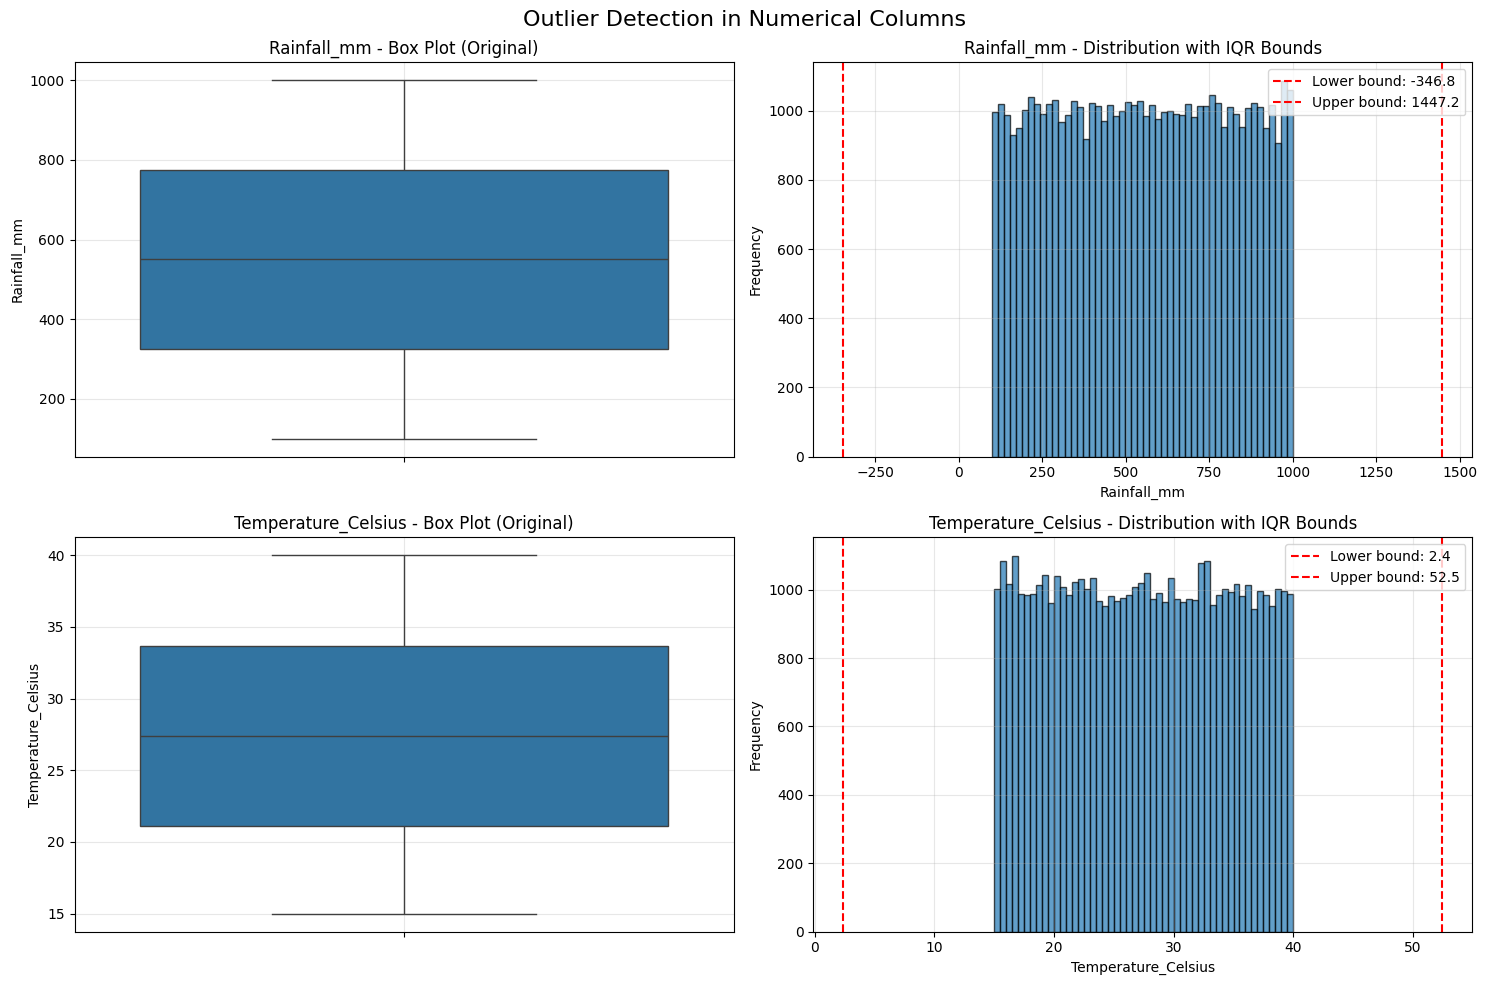


After clipping outliers:
Original dataset shape: (50000, 10)
Clipped dataset shape: (50000, 10)


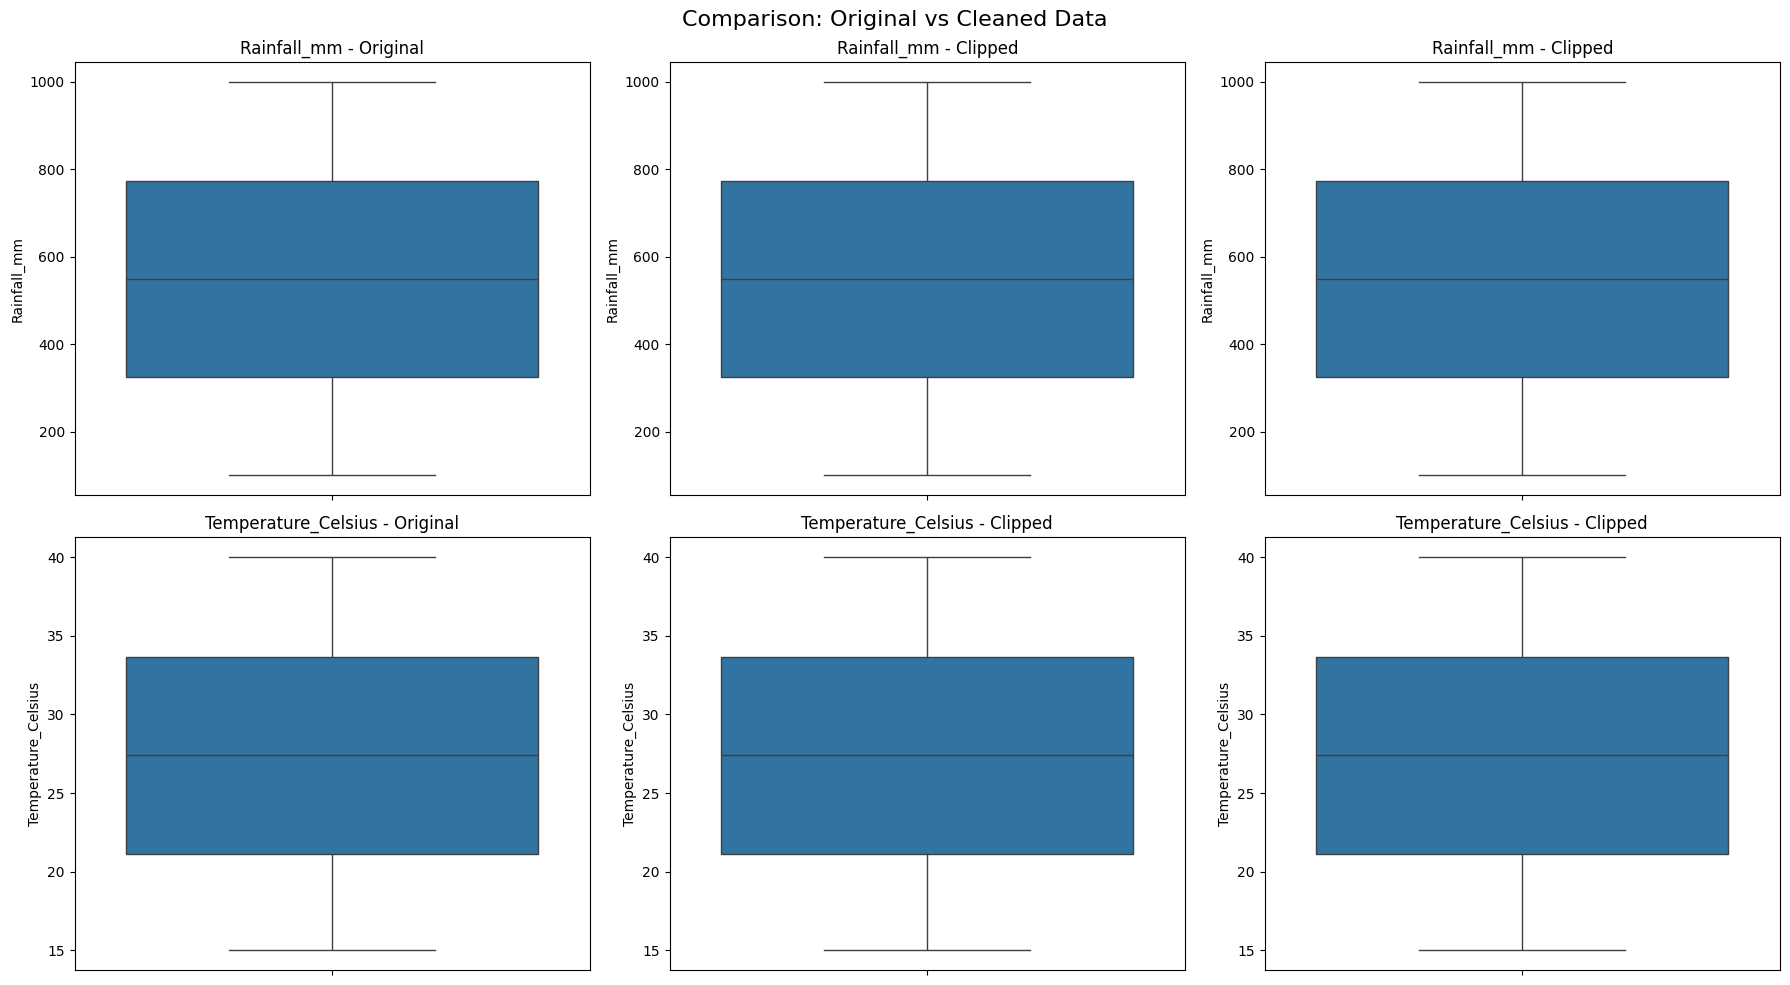

In [6]:
# Define function to detect outliers using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Detect outliers for numerical columns
numerical_cols = ['Rainfall_mm', 'Temperature_Celsius']
outliers_info = {}

print("Outlier Detection Results:")
print("=" * 50)

for col in numerical_cols:
    outliers, lower_bound, upper_bound = detect_outliers_iqr(df, col)
    outliers_info[col] = {
        'outliers': outliers,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'count': len(outliers)
    }
    
    print(f"\n{col}:")
    print(f"  Lower bound: {lower_bound:.2f}")
    print(f"  Upper bound: {upper_bound:.2f}")
    print(f"  Number of outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Outlier Detection in Numerical Columns', fontsize=16)

for i, col in enumerate(numerical_cols):
    # Box plot (original data)
    sns.boxplot(data=df, y=col, ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} - Box Plot (Original)')
    axes[i, 0].grid(True, alpha=0.3)
    
    # Histogram with outlier bounds
    axes[i, 1].hist(df[col], bins=50, alpha=0.7, edgecolor='black')
    axes[i, 1].axvline(outliers_info[col]['lower_bound'], color='red', linestyle='--', 
                       label=f'Lower bound: {outliers_info[col]["lower_bound"]:.1f}')
    axes[i, 1].axvline(outliers_info[col]['upper_bound'], color='red', linestyle='--', 
                       label=f'Upper bound: {outliers_info[col]["upper_bound"]:.1f}')
    axes[i, 1].set_title(f'{col} - Distribution with IQR Bounds')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('Frequency')
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Function to clip or remove outliers

def clip_outliers(data, columns, method='clip'):
    """
    Remove or clip outliers from specified columns
    """
    data_cleaned = data.copy()
    
    if method == 'clip':
        for col in columns:
            lower_bound = outliers_info[col]['lower_bound']
            upper_bound = outliers_info[col]['upper_bound']
            data_cleaned[col] = data_cleaned[col].clip(lower=lower_bound, upper=upper_bound)
            
    elif method == 'remove':
        for col in columns:
            lower_bound = outliers_info[col]['lower_bound']
            upper_bound = outliers_info[col]['upper_bound']
            data_cleaned = data_cleaned[
                (data_cleaned[col] >= lower_bound) & (data_cleaned[col] <= upper_bound)
            ]
    
    return data_cleaned

# Example: Clip outliers and update dataset
# Note: make sure to run the following lines after any change to df (e.g. re-sampling)
df_clipped = clip_outliers(df, numerical_cols, method='clip')
print(f"\nAfter clipping outliers:")
print(f"Original dataset shape: {df.shape}")
print(f"Clipped dataset shape: {df_clipped.shape}")

# Assign clipped data to df for downstream work
df = df_clipped.copy()

# Re-encode and rescale after cleaning

df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=False)

X = df_encoded.drop('Yield_tons_per_hectare', axis=1)
y = df_encoded['Yield_tons_per_hectare']

# Re-initialize scaler and scale numeric features
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numerical_cols + ['Days_to_Harvest']] = scaler.fit_transform(X[numerical_cols + ['Days_to_Harvest']])

# Example: Remove outliers if desired
# df_removed = clip_outliers(df, numerical_cols, method='remove')
# print(f"\nAfter removing outliers:")
# ...

# Compare distributions before and after cleaning (optional visualization)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comparison: Original vs Cleaned Data', fontsize=16)

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, y=col, ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} - Original')
    sns.boxplot(data=df_clipped, y=col, ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} - Clipped')
    sns.boxplot(data=df_removed if 'df_removed' in locals() else df_clipped, y=col, ax=axes[i, 2])
    axes[i, 2].set_title(f'{col} - Outliers Removed' if 'df_removed' in locals() else f'{col} - Clipped')

plt.tight_layout()
plt.show()

In [7]:
# Ensure that X_scaled and y are up to date and have matching lengths
if len(X_scaled) != len(y):
    # re-create features/target from the current df and re-scale
    print("Mismatch detected. Rebuilding X_scaled and y from df...")
    df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=False)
    X = df_encoded.drop('Yield_tons_per_hectare', axis=1)
    y = df_encoded['Yield_tons_per_hectare']
    scaler = StandardScaler()
    X_scaled = X.copy()
    X_scaled[numerical_cols + ['Days_to_Harvest']] = scaler.fit_transform(X[numerical_cols + ['Days_to_Harvest']])

print(f"Feature/target lengths -> X_scaled: {len(X_scaled)}, y: {len(y)}")

# Split into train and test sets with 80/20 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print("\nTest set shape:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

print(f"\nTrain/Test split ratio: {len(X_train)}/{len(X_test)} ({len(X_train)/len(X_scaled)*100:.1f}%/{len(X_test)/len(X_scaled)*100:.1f}%)")

Feature/target lengths -> X_scaled: 50000, y: 50000
Training set shape:
X_train: (40000, 24)
y_train: (40000,)

Test set shape:
X_test: (10000, 24)
y_test: (10000,)

Train/Test split ratio: 40000/10000 (80.0%/20.0%)


In [8]:
# Initialize the models
linear_reg = LinearRegression()
random_forest = RandomForestRegressor(n_estimators=100, random_state=42)
xgb_reg = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Fit the models on training data
print("Training Linear Regression...")
linear_reg.fit(X_train, y_train)

print("Training Random Forest Regressor...")
random_forest.fit(X_train, y_train)

print("Training XGBoost Regressor...")
xgb_reg.fit(X_train, y_train)

print("All models trained successfully!")

Training Linear Regression...
Training Random Forest Regressor...
Training XGBoost Regressor...
Training XGBoost Regressor...
All models trained successfully!
All models trained successfully!


In [9]:
# Make predictions on the test set
linear_pred = linear_reg.predict(X_test)
rf_pred = random_forest.predict(X_test)
xgb_pred = xgb_reg.predict(X_test)

# Calculate metrics for each model
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

# Calculate metrics for all models
linear_mae, linear_rmse, linear_r2 = calculate_metrics(y_test, linear_pred)
rf_mae, rf_rmse, rf_r2 = calculate_metrics(y_test, rf_pred)
xgb_mae, xgb_rmse, xgb_r2 = calculate_metrics(y_test, xgb_pred)

# Create a results dataframe for clean table format
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [linear_mae, rf_mae, xgb_mae],
    'RMSE': [linear_rmse, rf_rmse, xgb_rmse],
    'R² Score': [linear_r2, rf_r2, xgb_r2]
})

# Format the results for better display
results_df['MAE'] = results_df['MAE'].round(4)
results_df['RMSE'] = results_df['RMSE'].round(4)
results_df['R² Score'] = results_df['R² Score'].round(4)

print("=" * 60)
print("MODEL PERFORMANCE COMPARISON ON TEST SET")
print("=" * 60)
print(results_df.to_string(index=False))
print("=" * 60)
print("\nNote: Lower MAE and RMSE values indicate better performance.")
print("Higher R² score (closer to 1.0) indicates better performance.")

# Find the best performing model
best_model_idx = results_df['R² Score'].idxmax()
best_model = results_df.iloc[best_model_idx]['Model']
print(f"\nBest performing model: {best_model}")
print(f"Best R² Score: {results_df.iloc[best_model_idx]['R² Score']}")

MODEL PERFORMANCE COMPARISON ON TEST SET
            Model    MAE   RMSE  R² Score
Linear Regression 0.3968 0.4975    0.9134
    Random Forest 0.4154 0.5192    0.9057
          XGBoost 0.4012 0.5033    0.9114

Note: Lower MAE and RMSE values indicate better performance.
Higher R² score (closer to 1.0) indicates better performance.

Best performing model: Linear Regression
Best R² Score: 0.9134


/var/folders/s4/zrrjg1dx577dm70zqzvwnylm0000gn/T/ipykernel_41611/3687485542.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')


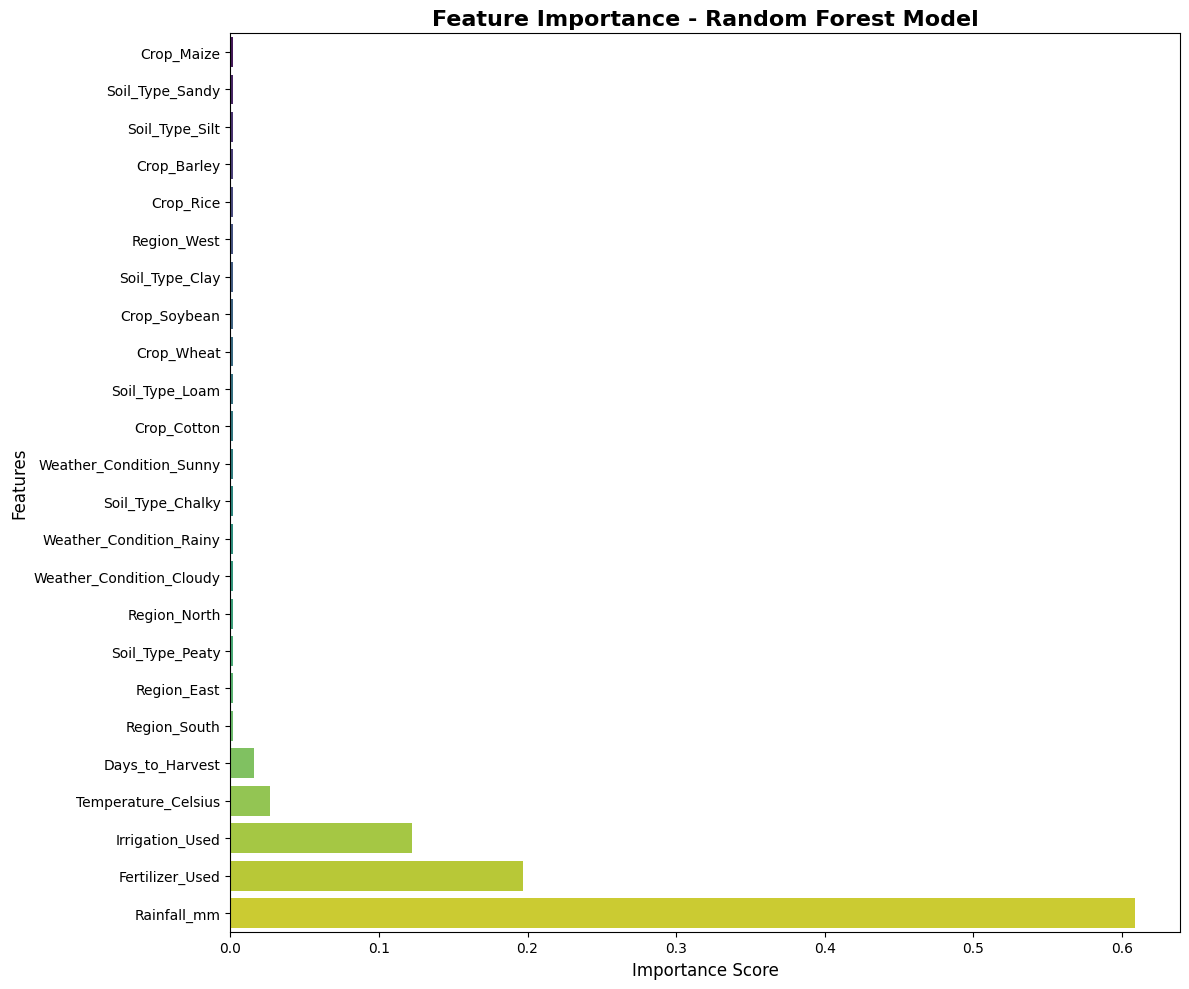

TOP 10 MOST IMPORTANT FEATURES
Weather_Condition_Cloudy      : 0.0016
Region_North                  : 0.0016
Soil_Type_Peaty               : 0.0016
Region_East                   : 0.0017
Region_South                  : 0.0017
Days_to_Harvest               : 0.0157
Temperature_Celsius           : 0.0265
Irrigation_Used               : 0.1221
Fertilizer_Used               : 0.1969
Rainfall_mm                   : 0.6086


In [10]:
# Get feature importance from the best performing model (Random Forest)
feature_importance = random_forest.feature_importances_
feature_names = X_train.columns

# Create a dataframe for easier plotting
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=True)

# Create horizontal bar chart
plt.figure(figsize=(12, 10))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance - Random Forest Model', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

# Print top 10 most important features
print("=" * 50)
print("TOP 10 MOST IMPORTANT FEATURES")
print("=" * 50)
top_features = importance_df.tail(10)
for idx, row in top_features.iterrows():
    print(f"{row['feature']:<30}: {row['importance']:.4f}")

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
import multiprocessing

# Get number of CPU cores safely
n_cores = max(1, multiprocessing.cpu_count() - 1)  # Leave one core free

# Smaller parameter space
param_distributions = {
    'n_estimators': randint(50, 150),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 10)
}

rf_random = RandomForestRegressor(random_state=42)

print(f"Performing RandomizedSearchCV on Random Forest using {n_cores} cores...")

random_search = RandomizedSearchCV(
    estimator=rf_random,
    param_distributions=param_distributions,
    n_iter=10,      # reduced from 50
    cv=3,           # reduced from 5
    scoring='r2',
    random_state=42,
    n_jobs=n_cores,  # Use specific number instead of -1
    verbose=1
)

random_search.fit(X_train, y_train)

print("=" * 60)
print("RANDOMIZED SEARCH RESULTS")
print("=" * 60)

print("Best parameters found:")
for param, value in random_search.best_params_.items():
    print(f"{param}: {value}")

print(f"\nBest cross-validation R² score: {random_search.best_score_:.4f}")

best_rf_model = random_search.best_estimator_

# Test evaluation
best_rf_pred = best_rf_model.predict(X_test)
best_rf_mae, best_rf_rmse, best_rf_r2 = calculate_metrics(y_test, best_rf_pred)

print("\nBest Random Forest Model Performance on Test Set:")
print(f"MAE: {best_rf_mae:.4f}")
print(f"RMSE: {best_rf_rmse:.4f}")
print(f"R² Score: {best_rf_r2:.4f}")

print("\nImprovement over original Random Forest:")
print(f"R² improvement: {best_rf_r2 - rf_r2:.4f}")

# Clean up multiprocessing resources
import gc
gc.collect()

Performing RandomizedSearchCV on Random Forest using 7 cores...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
RANDOMIZED SEARCH RESULTS
Best parameters found:
max_depth: 10
min_samples_split: 3
n_estimators: 113

Best cross-validation R² score: 0.9115

Best Random Forest Model Performance on Test Set:
MAE: 0.4027
RMSE: 0.5040
R² Score: 0.9112

Improvement over original Random Forest:
R² improvement: 0.0054
RANDOMIZED SEARCH RESULTS
Best parameters found:
max_depth: 10
min_samples_split: 3
n_estimators: 113

Best cross-validation R² score: 0.9115

Best Random Forest Model Performance on Test Set:
MAE: 0.4027
RMSE: 0.5040
R² Score: 0.9112

Improvement over original Random Forest:
R² improvement: 0.0054


17641

In [16]:
def predict_yield(region, soil_type, crop, rainfall_mm, temperature_celsius, 
                 fertilizer_used, irrigation_used, weather_condition, days_to_harvest):
    """
    Predict crop yield based on input features using the best trained model.
    
    Parameters:
    region (str): Region ('East', 'North', 'South', 'West')
    soil_type (str): Soil type ('Chalky', 'Clay', 'Loam', 'Peaty', 'Sandy', 'Silt')
    crop (str): Crop type ('Barley', 'Cotton', 'Maize', 'Rice', 'Soybean', 'Wheat')
    rainfall_mm (float): Rainfall in millimeters
    temperature_celsius (float): Temperature in Celsius
    fertilizer_used (int): 1 if fertilizer used, 0 if not
    irrigation_used (int): 1 if irrigation used, 0 if not
    weather_condition (str): Weather condition ('Cloudy', 'Rainy', 'Sunny')
    days_to_harvest (int): Number of days to harvest
    
    Returns:
    float: Predicted yield in tons per hectare
    """
    
    # Create a DataFrame with the input data
    input_data = pd.DataFrame({
        'Region': [region],
        'Soil_Type': [soil_type],
        'Crop': [crop],
        'Rainfall_mm': [rainfall_mm],
        'Temperature_Celsius': [temperature_celsius],
        'Fertilizer_Used': [fertilizer_used],
        'Irrigation_Used': [irrigation_used],
        'Weather_Condition': [weather_condition],
        'Days_to_Harvest': [days_to_harvest]
    })
    
    # Apply one-hot encoding (same as training data)
    input_encoded = pd.get_dummies(input_data, columns=categorical_columns, drop_first=False)
    
    # Ensure all columns from training data are present
    for col in X.columns:
        if col not in input_encoded.columns:
            input_encoded[col] = False
    
    # Reorder columns to match training data
    input_encoded = input_encoded.reindex(columns=X.columns, fill_value=False)
    
    # Scale numerical features
    input_scaled = input_encoded.copy()
    input_scaled[numerical_features] = scaler.transform(input_encoded[numerical_features])
    
    # Make prediction using the best model
    prediction = best_rf_model.predict(input_scaled)
    
    return prediction[0]

# Example usage
sample_prediction = predict_yield(
    region='North',
    soil_type='Loam',
    crop='Rice',
    rainfall_mm=800,
    temperature_celsius=25,
    fertilizer_used=1,
    irrigation_used=1,
    weather_condition='Sunny',
    days_to_harvest=120
)

print(f"Predicted yield: {sample_prediction:.2f} tons per hectare")

# Test with multiple examples
test_cases = [
    ('West', 'Sandy', 'Cotton', 900, 28, 0, 1, 'Cloudy', 122),
    ('South', 'Clay', 'Rice', 1000, 18, 1, 1, 'Rainy', 140),
    ('East', 'Silt', 'Wheat', 500, 20, 1, 0, 'Sunny', 100)
]

print("\nTest predictions:")
print("=" * 80)
for i, (region, soil, crop, rain, temp, fert, irrig, weather, days) in enumerate(test_cases, 1):
    pred = predict_yield(region, soil, crop, rain, temp, fert, irrig, weather, days)
    print(f"Case {i}: {region}, {soil}, {crop}, {rain}mm, {temp}°C, Fert:{fert}, Irrig:{irrig}, {weather}, {days}d")
    print(f"         Predicted yield: {pred:.2f} tons per hectare")
    print("-" * 80)

Predicted yield: 7.22 tons per hectare

Test predictions:
Case 1: West, Sandy, Cotton, 900mm, 28°C, Fert:0, Irrig:1, Cloudy, 122d
         Predicted yield: 6.37 tons per hectare
--------------------------------------------------------------------------------
Case 2: South, Clay, Rice, 1000mm, 18°C, Fert:1, Irrig:1, Rainy, 140d
         Predicted yield: 8.13 tons per hectare
--------------------------------------------------------------------------------
Case 3: East, Silt, Wheat, 500mm, 20°C, Fert:1, Irrig:0, Sunny, 100d
         Predicted yield: 4.50 tons per hectare
--------------------------------------------------------------------------------



Running SHAP Explainability for Linear Regression...


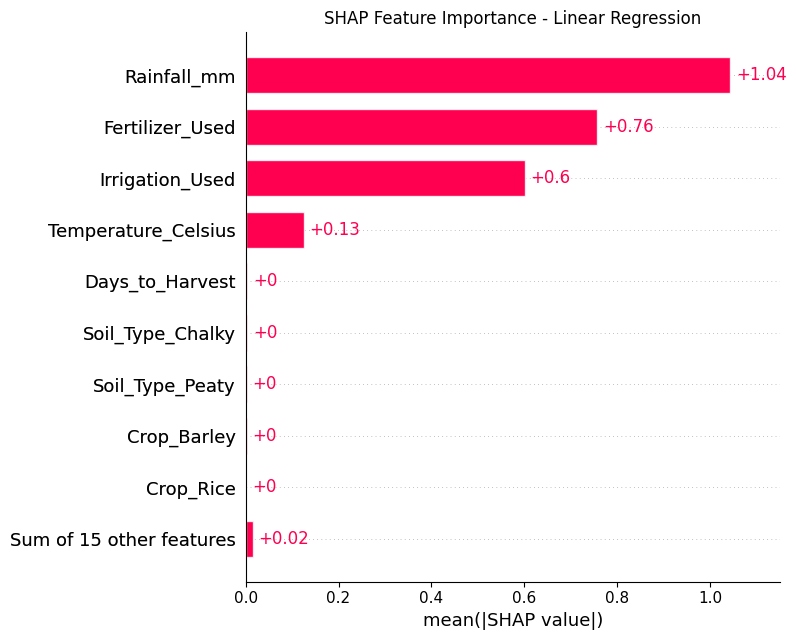

Explainable AI analysis completed!


In [20]:
import shap
import matplotlib.pyplot as plt

print("\nRunning SHAP Explainability for Linear Regression...")

# Take sample for faster computation
X_sample = X_train.sample(200, random_state=42)

# Create explainer (auto-detects model type)
explainer = shap.Explainer(linear_reg, X_train)

# Compute SHAP values
shap_values = explainer(X_sample)

# Global feature importance
plt.figure(figsize=(12,8))
shap.plots.bar(shap_values, show=False)
plt.title("SHAP Feature Importance - Linear Regression")
plt.tight_layout()
plt.show()


print("Explainable AI analysis completed!")